In [27]:
import pandas as pd
import numpy as np
# from google.colab import drive
# drive.mount('/content/gdrive')
# DATA_PATH = '/content/gdrive/MyDrive/REU/PROJECT/DATA/'
DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"

In [28]:
mi_df = pd.read_csv(DATA_PATH+"mi_transactors.csv")
mi_df.head()

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN


<h1>TRANSACTOR TYPES COLUMNS</h1>

In [29]:
print("transactor types labels:", mi_df.transactor_type.unique())
print()
print("transactor type specific labels:", mi_df.transactor_type_specific.unique())

transactor types labels: [nan 'Organization']

transactor type specific labels: [nan 'Committee' 'Candidate Committee' 'Party']


In [31]:
mi_df.groupby(by='transactor_type', dropna=False).size()

transactor_type
Organization      12205
NaN             1944806
dtype: int64

In [32]:
total = mi_df.groupby(by='transactor_type', dropna=False).size().sum()
total

1957011

In [33]:
mi_df.groupby(by='transactor_type', dropna=False).size()/total

transactor_type
Organization    0.006237
NaN             0.993763
dtype: float64

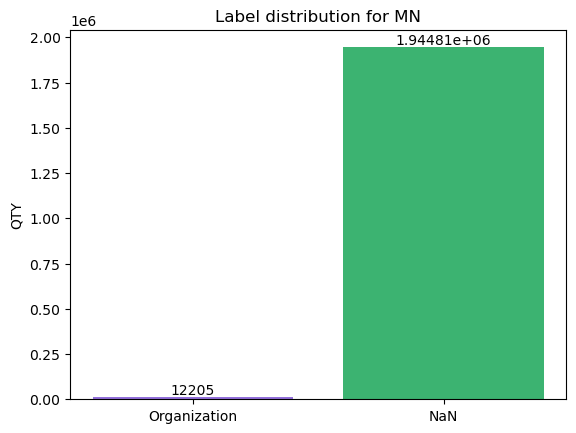

In [34]:
import matplotlib.pyplot as plt

def label_distribution(labels, groupby_df, colors, graph_name):
    fig, ax = plt.subplots()
    ax.bar(labels, groupby_df)

    bars = ax.bar(labels, counts, color = colors)
    ax.bar_label(bars)

    ax.set_ylabel('QTY')
    ax.set_title('Label distribution for MN')

    # plt.savefig(graph_name, transparent=True, bbox_inches = 'tight')
    plt.show()
    

mi_df_labels = ['Organization', 'NaN']
counts = mi_df.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']

label_distribution(mi_df_labels, counts, colors, 'mi-label-distribution.png')


<h1>NAMES COLUMNS</h1>

In [35]:
mi_df[['full_name', 'last_name', 'first_name', 'name_preferred']]

,full_name,last_name,first_name,name_preferred
0,BUTZEL LONG,NaN,NaN,NaN
1,PAVILION TOWNSHIP,NaN,NaN,NaN
2,DOOZIES ICE CREAM,NaN,NaN,NaN
3,ALWOOD LANDSCAPING & NURSERY,NaN,NaN,NaN
4,EXPLORE CHIROPRACTIC,NaN,NaN,NaN
...,...,...,...,...
1957006,ELECT PADMA KUPPA,NaN,NaN,ELECT PADMA KUPPA
1957007,COMMITTEE TO ELECT MARY CAVANAGH,NaN,NaN,COMMITTEE TO ELECT MARY CAVANAGH
1957008,COMMITTEE TO ELECT RON L. HAYWOOD,NaN,NaN,COMMITTEE TO ELECT RON L. HAYWOOD
1957009,MICHIGAN LAND TITLE ASSOCIATION POLITICAL ACTI...,NaN,NaN,MICHIGAN LAND TITLE ASSOCIATION POLI


<h1>NaN Values</h1>

<h2>TRANSACTOR_TYPE == NaN => TRASNASCTOR_TYPE_SPECIFIC == NaN</h2>

In [36]:
""""transactor_type == NaN"""
mi_df[mi_df['transactor_type'].isna()].head()

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN


In [37]:
""""transactor_type_specific == NaN"""
mi_df[mi_df['transactor_type_specific'].isna()].head()

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN


In [38]:
""""Nan == full_name == last_name == first_name == name_preferred"""

mi_df[mi_df[['full_name', 'last_name', 'first_name', 'name_preferred']].isna().all(axis=1)]


,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific
265896,NaN,MI,a5a95660-651c-429e-b2bf-1e1dde2a06ef,NaN,NaN,NaN,NaN,NaN
290395,NaN,MI,124ef90d-a5c0-41f5-a2f4-436bf299d077,NaN,NaN,NaN,NaN,NaN
292270,NaN,MI,cbf7d397-5f81-4ebf-92ac-009714563646,NaN,NaN,NaN,NaN,NaN
292271,NaN,MI,d8cbcdbb-65d1-4943-8792-2a576053b3fa,NaN,NaN,NaN,NaN,NaN
983296,NaN,MI,8caa6b46-55fb-4aab-9fba-501797e39aa4,NaN,NaN,NaN,NaN,NaN
1418413,NaN,MI,f57fe7d0-de7b-4b9b-9eb4-df03a9cb96b8,NaN,NaN,NaN,NaN,NaN
1465172,NaN,MI,3f35f3e3-6045-4b1b-b9af-c89c4399c44d,NaN,NaN,NaN,NaN,NaN
1472828,NaN,MI,84f40f45-99f2-4126-b115-5f77d8aaa9a7,NaN,NaN,NaN,NaN,NaN
1778609,NaN,MI,650671f3-45d0-43a2-94ee-9a81833685d9,NaN,NaN,NaN,NaN,NaN
1834706,NaN,MI,30708f35-1307-4dd7-b6b9-71b0879a6524,NaN,NaN,NaN,NaN,NaN


In [39]:
no_names_mi_df = mi_df.dropna(subset=['full_name', 'last_name', 'first_name', 'name_preferred'], how='all').copy()
no_names_mi_df

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1957006,ELECT PADMA KUPPA,MI,b494e4fc-32d4-4af4-900b-b816ee09e342,NaN,NaN,ELECT PADMA KUPPA,Organization,Candidate Committee
1957007,COMMITTEE TO ELECT MARY CAVANAGH,MI,fa2c12e0-31d0-4dc9-b03a-20301f143cee,NaN,NaN,COMMITTEE TO ELECT MARY CAVANAGH,Organization,Candidate Committee
1957008,COMMITTEE TO ELECT RON L. HAYWOOD,MI,58f3768a-8728-40c3-af82-e779239a350b,NaN,NaN,COMMITTEE TO ELECT RON L. HAYWOOD,Organization,Candidate Committee
1957009,MICHIGAN LAND TITLE ASSOCIATION POLITICAL ACTI...,MI,fa4725c4-a81b-4428-a2c9-af385d3435bc,NaN,NaN,MICHIGAN LAND TITLE ASSOCIATION POLI,Organization,Committee


<h1>MERGED NAMES COLUMNS</h1>

In [40]:
#  MERGE NAMES COLUMNS
no_names_mi_df['merged_full_name'] =  no_names_mi_df['first_name'].astype(str) + ' ' + no_names_mi_df['last_name'].astype(str) + ' ' + no_names_mi_df['name_preferred'].astype(str) + ' ' + no_names_mi_df['full_name'].astype(str)
no_names_mi_df

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific,merged_full_name
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN,nan nan nan BUTZEL LONG
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN,nan nan nan PAVILION TOWNSHIP
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN,nan nan nan DOOZIES ICE CREAM
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN,nan nan nan ALWOOD LANDSCAPING & NURSERY
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN,nan nan nan EXPLORE CHIROPRACTIC
...,...,...,...,...,...,...,...,...,...
1957006,ELECT PADMA KUPPA,MI,b494e4fc-32d4-4af4-900b-b816ee09e342,NaN,NaN,ELECT PADMA KUPPA,Organization,Candidate Committee,nan nan ELECT PADMA KUPPA ELECT PADMA KUPPA
1957007,COMMITTEE TO ELECT MARY CAVANAGH,MI,fa2c12e0-31d0-4dc9-b03a-20301f143cee,NaN,NaN,COMMITTEE TO ELECT MARY CAVANAGH,Organization,Candidate Committee,nan nan COMMITTEE TO ELECT MARY CAVANAGH COMMI...
1957008,COMMITTEE TO ELECT RON L. HAYWOOD,MI,58f3768a-8728-40c3-af82-e779239a350b,NaN,NaN,COMMITTEE TO ELECT RON L. HAYWOOD,Organization,Candidate Committee,nan nan COMMITTEE TO ELECT RON L. HAYWOOD COMM...
1957009,MICHIGAN LAND TITLE ASSOCIATION POLITICAL ACTI...,MI,fa4725c4-a81b-4428-a2c9-af385d3435bc,NaN,NaN,MICHIGAN LAND TITLE ASSOCIATION POLI,Organization,Committee,nan nan MICHIGAN LAND TITLE ASSOCIATION POLI M...


In [41]:
no_names_mi_df['merged_full_name'] = no_names_mi_df['merged_full_name'].str.replace('nan', '', regex=False).str.strip()

In [42]:
no_names_mi_df['merged_full_name'] = no_names_mi_df['merged_full_name'].str.lower()
no_names_mi_df

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific,merged_full_name
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN,butzel long
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN,pavilion township
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN,doozies ice cream
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN,alwood landscaping & nursery
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN,explore chiropractic
...,...,...,...,...,...,...,...,...,...
1957006,ELECT PADMA KUPPA,MI,b494e4fc-32d4-4af4-900b-b816ee09e342,NaN,NaN,ELECT PADMA KUPPA,Organization,Candidate Committee,elect padma kuppa elect padma kuppa
1957007,COMMITTEE TO ELECT MARY CAVANAGH,MI,fa2c12e0-31d0-4dc9-b03a-20301f143cee,NaN,NaN,COMMITTEE TO ELECT MARY CAVANAGH,Organization,Candidate Committee,committee to elect mary cavanagh committee to ...
1957008,COMMITTEE TO ELECT RON L. HAYWOOD,MI,58f3768a-8728-40c3-af82-e779239a350b,NaN,NaN,COMMITTEE TO ELECT RON L. HAYWOOD,Organization,Candidate Committee,committee to elect ron l. haywood committee to...
1957009,MICHIGAN LAND TITLE ASSOCIATION POLITICAL ACTI...,MI,fa4725c4-a81b-4428-a2c9-af385d3435bc,NaN,NaN,MICHIGAN LAND TITLE ASSOCIATION POLI,Organization,Committee,michigan land title association poli michigan ...


<h3>Duplicate names</h3>

In [43]:
# DUPLICATE NAMES
no_names_mi_df.groupby(by='merged_full_name').size().sort_values()

merged_full_name
karianne               soulsby          1
linda                  pickel           1
linda                  phelps           1
linda                  phelan           1
linda                  pfotenhauer      1
                                     ... 
self                                  439
self employed                         468
self-employed                         473
not employed                          545
retired                               708
Length: 709801, dtype: int64

<h3>DROP DUPLICATE NAMES</h3>

In [44]:

# DROP DUPLICATE NAMES
no_duplicate_names = no_names_mi_df.drop_duplicates(subset='merged_full_name').copy()
no_duplicate_names.groupby(by='merged_full_name').size().sort_values()


merged_full_name
                                  1
mi council for maternal & chil    1
mi council maternal child         1
mi council nurse prac pac         1
mi council nurse pract pac        1
                                 ..
giraldez daniel                   1
girard                 dion       1
girard                 ryan       1
giovonni               lobato     1
|rev. ruh              fatur      1
Length: 709801, dtype: int64

In [45]:
no_duplicate_names

,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific,merged_full_name
0,BUTZEL LONG,MI,7d336795-bb57-4cec-8aee-b1f12b2432f4,NaN,NaN,NaN,NaN,NaN,butzel long
1,PAVILION TOWNSHIP,MI,93c14a02-1920-4bd6-ab51-8b655bf59045,NaN,NaN,NaN,NaN,NaN,pavilion township
2,DOOZIES ICE CREAM,MI,a5c8fa3c-d905-4837-8eb9-2aae382088df,NaN,NaN,NaN,NaN,NaN,doozies ice cream
3,ALWOOD LANDSCAPING & NURSERY,MI,eca9e7d8-d878-4b31-835f-050f1e0aadbd,NaN,NaN,NaN,NaN,NaN,alwood landscaping & nursery
4,EXPLORE CHIROPRACTIC,MI,9c27446c-9bb9-4537-af16-4212b7ea2ded,NaN,NaN,NaN,NaN,NaN,explore chiropractic
...,...,...,...,...,...,...,...,...,...
1956694,MEMO ENTRY,MI,0db39414-569a-4272-ad1b-d3ec92e5b5b5,NaN,NaN,NaN,NaN,NaN,memo entry
1956696,THE CTE TO ELECT JENNIFER JOHNSEN FO,MI,09696f54-30dd-4dbf-b7e2-9008bdf28df1,NaN,NaN,NaN,NaN,NaN,the cte to elect jennifer johnsen fo
1956703,GAGNON,MI,ed387cb5-5410-4f94-a0c4-3c6f5fa645a0,DAVID,NaN,NaN,NaN,NaN,david gagnon
1956831,NaN,MI,0f9b2c7f-4928-44e7-a41a-796057d5eb3c,DOUGLAS,WAGGENER,NaN,NaN,NaN,douglas waggener


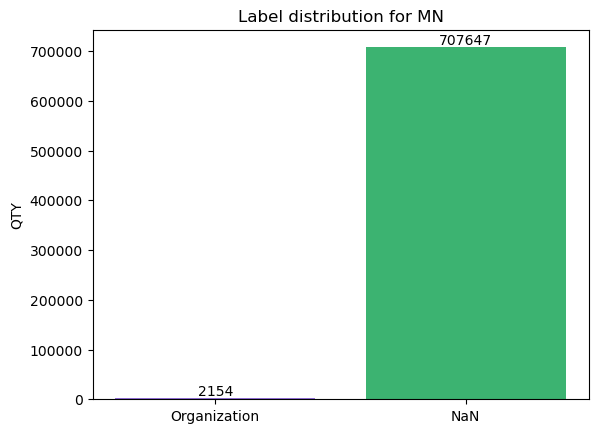

In [ ]:
mi_df_labels = ['Organization', 'NaN']
counts = no_duplicate_names.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']
label_distribution(mi_df_labels, counts, colors,'Mi-Label-distribution-non-duplicate-name.png')

In [48]:
mi_df_annotated_data = no_duplicate_names.dropna(subset=['transactor_type']).copy()
mi_df_annotated_data


,full_name,reported_state,id,first_name,last_name,name_preferred,transactor_type,transactor_type_specific,merged_full_name
1667,BUTZEL LONG POLITICAL ACTION COMMITTEE,MI,b5054d6c-8f63-4329-ad22-dcb4f9c56151,NaN,NaN,BUTZEL LONG PAC,Organization,Committee,butzel long pac butzel long political action c...
1668,RETIRED DETROIT POLICE AND FIRE ASSN PAC,MI,7d5eb442-7f52-455f-827a-6c5d5c8c7f33,NaN,NaN,RETIRED DETROIT POLICE/FIRE ASSN PAC,Organization,Committee,retired detroit police/fire assn pac retired d...
1669,COMMITTEE TO ELECT GENE HAYMAKER,MI,10e46c82-b034-496a-a89f-37f8e702756e,NaN,NaN,COMMITTEE TO ELECT GENE HAYMAKER,Organization,Candidate Committee,committee to elect gene haymaker committee to ...
1670,JACK COLEMAN FOR STATE REPRESENTATIVE,MI,34acf911-0dd8-4bdd-b2c8-9f59fbfb858c,NaN,NaN,JACK COLEMAN FOR STATE REPRESENTATIV,Organization,Candidate Committee,jack coleman for state representativ jack cole...
1671,TUSCOLA COUNTY REPUBLICAN PARTY,MI,f80a8fad-4010-4189-beb7-a7312b9eef5a,NaN,NaN,TUSCOLA COUNTY REPUBLICAN PARTY,Organization,Party,tuscola county republican party tuscola county...
...,...,...,...,...,...,...,...,...,...
1954544,COMMITTEE TO ELECT JEREMIAH BUFFALO WIRGAU PRO...,MI,a290599a-c92b-402f-a1cb-a987383afa3b,NaN,NaN,COMMITTEE TO ELECT JEREMIAH BUFFALO,Organization,Candidate Committee,committee to elect jeremiah buffalo committee ...
1954579,JONATHAN HOOVER,MI,ba427bdc-295c-462c-a7fb-4ab0f7a4172f,NaN,NaN,JONATHAN HOOVER,Organization,Candidate Committee,jonathan hoover jonathan hoover
1955959,MILLER FOR MICHIGAN,MI,2558d7b7-6315-430c-b0e3-c9caa2a0b400,NaN,NaN,MILLER FOR MICHIGAN,Organization,Committee,miller for michigan miller for michigan
1956014,SOUTHWEST MICHIGAN BUILDING TRADES PAC,MI,0bca3542-0dcd-45c0-9f31-ea6754517a34,NaN,NaN,SOUTHWEST MICHIGAN BUILDING TRADES P,Organization,Committee,southwest michigan building trades p southwest...


In [49]:
mi_df_annotated_data.groupby(by='transactor_type', dropna=False).size()

transactor_type
Organization    2154
dtype: int64

In [51]:
mi_df_non_annotated_data = no_duplicate_names[no_duplicate_names['transactor_type'].isna()].copy()
mi_df_non_annotated_data.groupby(by='transactor_type', dropna=False).size()

transactor_type
NaN    707647
dtype: int64

In [ ]:
mi_df_annotated_data.to_csv("mi_annotated_data.csv")
mi_df_non_annotated_data.to_csv("mi_non_annotated_data.csv")